# Control Variables - 11 Caloric Density Index
18/05/2026, Kuba Kowalski 

In [1]:
import importlib
import subprocess
import sys

packages = ["geopandas", "rasterio", "shapely", "numpy", "pandas"]

for package in packages:
    try:
        importlib.import_module(package)
        print(f"{package}: already installed")
    except ImportError:
        print(f"{package}: installing")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("Installation check complete.")

geopandas: already installed
rasterio: already installed
shapely: already installed
numpy: already installed
pandas: already installed
Installation check complete.


In [2]:
from pathlib import Path
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import numpy as np
import pandas as pd

In [3]:
# Paths - IN
province_polygons = Path(r"C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\99all\geom_edu_residence_all_with_cote.geojson")
csi_raster = Path(r"C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\1_inputs\ancilliary_data\11_caloric_density_index\CaloricSuitabilityIndex\post1500AverageCaloriesNo0.tif")

# Paths - OUT 
out_dir = Path(
    r"C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index"
)
out_dir.mkdir(exist_ok=True)

In [4]:
# Load & inspect

provinces = gpd.read_file(province_polygons)

with rasterio.open(csi_raster) as src:
    raster_crs = src.crs
    raster_nodata = src.nodata
    raster_res = src.res

print("Province columns:")
print(provinces.columns)

print("\nProvince CRS:")
print(provinces.crs)

print("\nRaster CRS:")
print(raster_crs)

print("\nRaster NoData:")
print(raster_nodata)

print("\nRaster resolution:")
print(raster_res)

# Reproject provinces to raster CRS
provinces = provinces.to_crs(raster_crs)

# Province identifier
zone_id = "GEOLEVEL1"

Province columns:
Index(['country_id', 'country', 'GEOLEVEL1', 'cohort', 'primary_educ',
       'higher_educ', 'tertiary_educ', 'n', 'geometry'],
      dtype='object')

Province CRS:
EPSG:4326

Raster CRS:
GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]

Raster NoData:
-9.0

Raster resolution:
(0.08333333333333333, 0.08333333333333333)


In [5]:
# Functions

# Gini 
    # Calculates Gini coefficient of cell values used for province mean calculation 

def gini(values):

    values = np.asarray(values, dtype="float64")

    # Remove NaN values
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan

    # If all values are zero
    if np.all(values == 0):
        return 0.0

    # Sort values
    values = np.sort(values)

    n = len(values)

    index = np.arange(1, n + 1)

    # Gini formula
    return float(
        (2 * np.sum(index * values)) / (n * np.sum(values))
        - (n + 1) / n
    )

In [7]:
# Clean province geometries before extraction
    ## Needed for residence for some reason. Likely an artefact from Ethiopia or Rwanda due to an empty lakes object. 
provinces = provinces.copy()

provinces["geometry"] = provinces.geometry.make_valid()

provinces = provinces[
    provinces.geometry.notna() &
    ~provinces.geometry.is_empty
].copy()

print("Valid province geometries:", len(provinces))

Valid province geometries: 2139


In [8]:
# Execute calculation

rows = []

with rasterio.open(csi_raster) as src:

    nodata = src.nodata

    for _, row in provinces.iterrows():

        try:
            if row.geometry is None or row.geometry.is_empty:
                raise ValueError("Missing or empty geometry")

            geom = [mapping(row.geometry)]

            out_image, _ = mask(
                src,
                geom,
                crop=True,
                filled=True
            )

            values = out_image[0].astype("float64")

            if nodata is not None:
                values = values[values != nodata]

            values = values[~np.isnan(values)]

            if len(values) == 0:
                mean_val = np.nan
                sd_val = np.nan
                gini_val = np.nan
                count_val = 0
            else:
                mean_val = float(np.mean(values))
                sd_val = float(np.std(values))
                gini_val = gini(values)
                count_val = int(len(values))

            rows.append({
                zone_id: row[zone_id],
                "csi_mean": mean_val,
                "csi_sd": sd_val,
                "csi_gini": gini_val,
                "csi_cell_count": count_val
            })

        except Exception as e:
            print(f"Skipping {row.get(zone_id, 'unknown')}: {e}")

            rows.append({
                zone_id: row[zone_id],
                "csi_mean": np.nan,
                "csi_sd": np.nan,
                "csi_gini": np.nan,
                "csi_cell_count": 0
            })


print("Extraction complete.")

Extraction complete.


In [9]:
# Export 

# Create dataframe for export 

csi_stats = pd.DataFrame(rows)
csi_stats.head()

# Export CSV

csv_path = out_dir / "11_province_csi_mean_sd_gini.csv"
csi_stats.to_csv(csv_path, index=False)
print(csv_path)

# Re-join to spatial file

provinces_csi = provinces.merge(
    csi_stats,
    on=zone_id
)

# Export spatial file 

gpkg_path = out_dir / "11_province_csi_mean_sd_gini.gpkg"
provinces_csi.to_file(
    gpkg_path,
    driver="GPKG"
)
print(gpkg_path)

C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index\11_province_csi_mean_sd_gini.csv
C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index\11_province_csi_mean_sd_gini.gpkg


In [10]:
# Joys of visualization


# Packages 
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

# ---- paths ----
africa_outline_file = r"C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\1_inputs\IPUMS_boundaries\world_countries_africa_only.json"

map_output_dir = out_dir / "maps"
map_output_dir.mkdir(exist_ok=True)

# ---- load Africa outline ----
africa = gpd.read_file(africa_outline_file)

if africa.crs != provinces_csi.crs:
    africa = africa.to_crs(provinces_csi.crs)

# ---- variables to map ----
variables = {
    "csi_mean": "Mean caloric suitability",
    "csi_sd": "Standard deviation of caloric suitability",
    "csi_gini": "Gini of caloric suitability"
}

for var, label in variables.items():

    gdf_plot = provinces_csi[provinces_csi[var].notna()].copy()

    values = gdf_plot[var].dropna().values

    if len(values) == 0:
        print(f"Skipping {var}: no valid values")
        continue

    vmin = values.min()
    vmax = values.max()

    fig, ax = plt.subplots(figsize=(16, 20))

    # ---- Africa background outline ----
    africa.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgrey",
        linewidth=0.5
    )

    # ---- province layer ----
    gdf_plot.plot(
        column=var,
        cmap="viridis",
        linewidth=0.4,
        edgecolor="black",
        legend=False,
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(label)
    ax.set_axis_off()

    # ---- fixed Africa-wide extent ----
    minx, miny, maxx, maxy = africa.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    # ---- horizontal colorbar ----
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        fraction=0.05,
        pad=0.04
    )

    cbar.set_label(label)

    # ---- wave axis above colorbar ----
    cb_pos = cbar.ax.get_position()

    wave_ax = fig.add_axes([
        cb_pos.x0,
        cb_pos.y1 + 0.005,
        cb_pos.width,
        0.05
    ])

    mean_val = values.mean()
    min_val = values.min()
    max_val = values.max()

    fig.text(
        0.5,
        0.02,
        f"Mean: {mean_val:.3f}   Min: {min_val:.3f}   Max: {max_val:.3f}",
        ha="center",
        fontsize=10
    )

    if len(values) > 1 and vmin < vmax:
        kde = gaussian_kde(values)
        x = np.linspace(vmin, vmax, 300)
        y = kde(x)

        wave_ax.plot(x, y, linewidth=1.5)
        wave_ax.fill_between(x, y, alpha=0.25)

    wave_ax.set_xlim(vmin, vmax)
    wave_ax.set_xticks([])
    wave_ax.set_yticks([])

    for spine in wave_ax.spines.values():
        spine.set_visible(False)

    # ---- save ----
    out_file = map_output_dir / f"{var}_map.png"

    plt.savefig(
        out_file,
        dpi=800,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {out_file}")

print("Done.")


Saved: C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index\maps\csi_mean_map.png
Saved: C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index\maps\csi_sd_map.png
Saved: C:\Users\kowal010\Documents\rhi\research_assistant_rhi2026_africa\3_outputs\control_variables\11_caloric_density_index\maps\csi_gini_map.png
Done.


## Sanity check

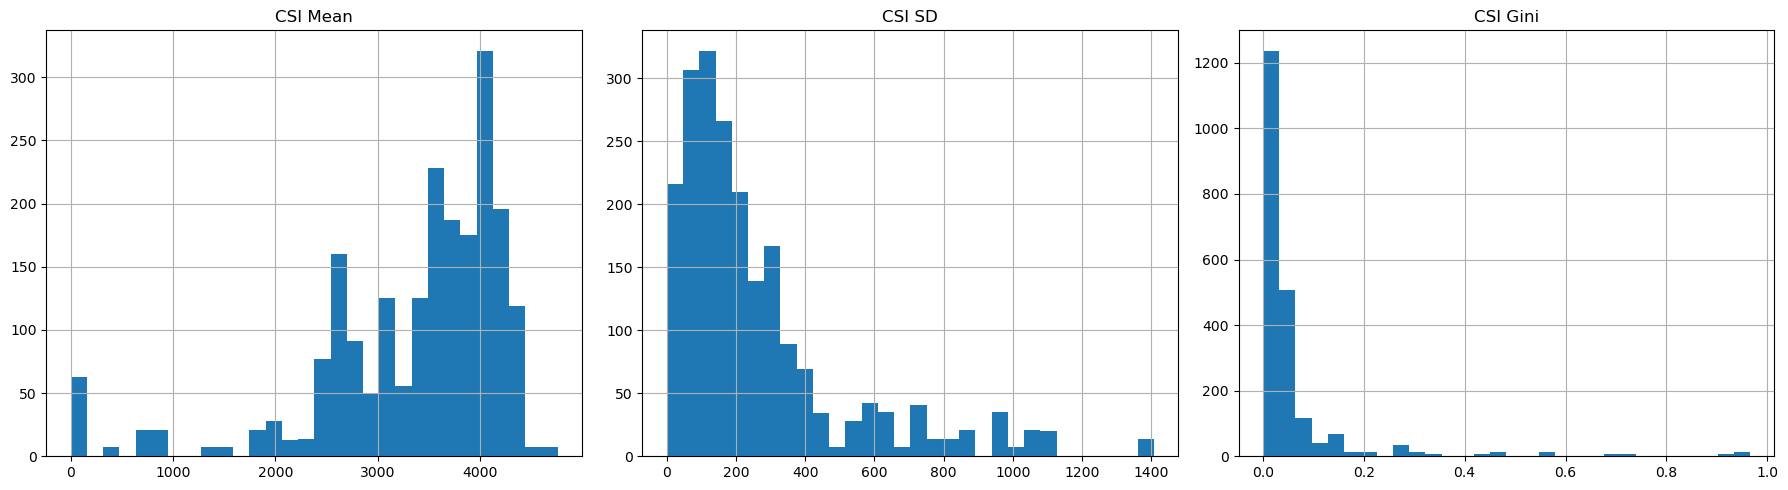

In [11]:
# Histograms

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

csi_stats["csi_mean"].hist(ax=axes[0], bins=30)
axes[0].set_title("CSI Mean")

csi_stats["csi_sd"].hist(ax=axes[1], bins=30)
axes[1].set_title("CSI SD")

csi_stats["csi_gini"].hist(ax=axes[2], bins=30)
axes[2].set_title("CSI Gini")

plt.tight_layout()
plt.show()

In [12]:
#Lowest values
csi_stats.sort_values("csi_mean").head(10)

,GEOLEVEL1,csi_mean,csi_sd,csi_gini,csi_cell_count
86,072004,0.0,0.0,0.0,1
87,072004,0.0,0.0,0.0,1
88,072004,0.0,0.0,0.0,1
89,072004,0.0,0.0,0.0,1
90,072004,0.0,0.0,0.0,1
1928,729011,0.0,0.0,0.0,4534
1931,729011,0.0,0.0,0.0,4534
1930,729011,0.0,0.0,0.0,4534
1929,729011,0.0,0.0,0.0,4534
1923,729021,0.0,0.0,0.0,2689


In [13]:
# Highest values
csi_stats.sort_values("csi_mean", ascending=False).head(10)

,GEOLEVEL1,csi_mean,csi_sd,csi_gini,csi_cell_count
380,231014,4761.449079,161.051050,0.018574,7
384,231014,4761.449079,161.051050,0.018574,7
382,231014,4761.449079,161.051050,0.018574,7
379,231014,4761.449079,161.051050,0.018574,7
378,231014,4761.449079,161.051050,0.018574,7
383,231014,4761.449079,161.051050,0.018574,7
381,231014,4761.449079,161.051050,0.018574,7
1349,834014,4512.357441,179.682725,0.022608,887
1372,834014,4512.357441,179.682725,0.022608,887
1280,834014,4512.357441,179.682725,0.022608,887


In [14]:
# Missing values
csi_stats.isna().sum()

GEOLEVEL1          0
csi_mean          14
csi_sd            14
csi_gini          14
csi_cell_count     0
dtype: int64